# OPTIMALISASI PREDIKSI CUSTOMER CHURN
## Sebuah Studi Komparatif Pendekatan Machine Learning untuk Peningkatan Retensi Pelanggan di Sektor Telekomunikasi

**Arnetha Marchelina — 2702397141**  
Computer Science Study Program, BINUS Online, Universitas Bina Nusantara

---

**Pipeline:**
1. Setup & Import Libraries
2. Data Loading & EDA
3. Text Preprocessing (Sastrawi + Regex)
4. Multi-Signal Proxy Labeling (Churn Risk Score)
5. Feature Engineering (TF-IDF + Metadata)
6. Data Splitting & SMOTE
7. Comparative Modeling (LR, RF, XGBoost)
8. Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
9. Feature Importance & Churn Analysis
10. Save All Outputs

---
## 1. Setup & Import Libraries

In [1]:
import os, re, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.sparse as sp
from collections import Counter
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from textblob import TextBlob
import swifter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

BASE_DIR    = os.path.dirname(os.path.abspath('__file__'))
OUTPUT_DIR  = os.path.join(BASE_DIR, 'outputs')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
MODELS_DIR  = os.path.join(OUTPUT_DIR, 'models')
DATA_DIR    = os.path.join(OUTPUT_DIR, 'data')
for d in [OUTPUT_DIR, FIGURES_DIR, MODELS_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

DATASET_PATH = (
    '/Users/marchelinaa/Library/CloudStorage/'
    'OneDrive-DANAINDONESIA/Backup/College/Thesis/'
    'Soft Cover/Data/telkomsel_data_scrap.xlsx'
)
RANDOM_STATE = 42
print('All libraries loaded successfully.')
print(f'Output directory: {OUTPUT_DIR}')

All libraries loaded successfully.
Output directory: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs


---
## 2. Data Loading & Exploratory Data Analysis (EDA)

In [2]:
print('Loading dataset...')
df = pd.read_excel(DATASET_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Loading dataset...


Dataset shape: (172619, 11)
Columns: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [3]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Data Types:
reviewId                        object
userName                        object
userImage                       object
content                         object
score                            int64
thumbsUpCount                    int64
reviewCreatedVersion            object
at                      datetime64[ns]
replyContent                    object
repliedAt               datetime64[ns]
appVersion                      object
dtype: object

Missing Values:
reviewId                    0
userName                    0
userImage                   0
content                     6
score                       0
thumbsUpCount               0
reviewCreatedVersion    34163
at                          0
replyContent            42435
repliedAt               42435
appVersion              34163
dtype: int64


In [4]:
rating_dist = df['score'].value_counts().sort_index()
rating_pct  = (rating_dist / len(df) * 100).round(1)
rating_table = pd.DataFrame({
    'Kategori': ['Sangat Buruk','Buruk','Netral','Baik','Sangat Baik'],
    'Jumlah'  : rating_dist.values,
    'Persentase (%)': rating_pct.values
}, index=rating_dist.index)
rating_table.index.name = 'Rating'
print('Distribusi Rating Pengguna (Table 11):')
print(rating_table.to_string())
print(f'\nTotal: {len(df):,}')

Distribusi Rating Pengguna (Table 11):
            Kategori  Jumlah  Persentase (%)
Rating                                      
1       Sangat Buruk   88075            51.0
2              Buruk   13667             7.9
3             Netral   11510             6.7
4               Baik   10082             5.8
5        Sangat Baik   49285            28.6

Total: 172,619


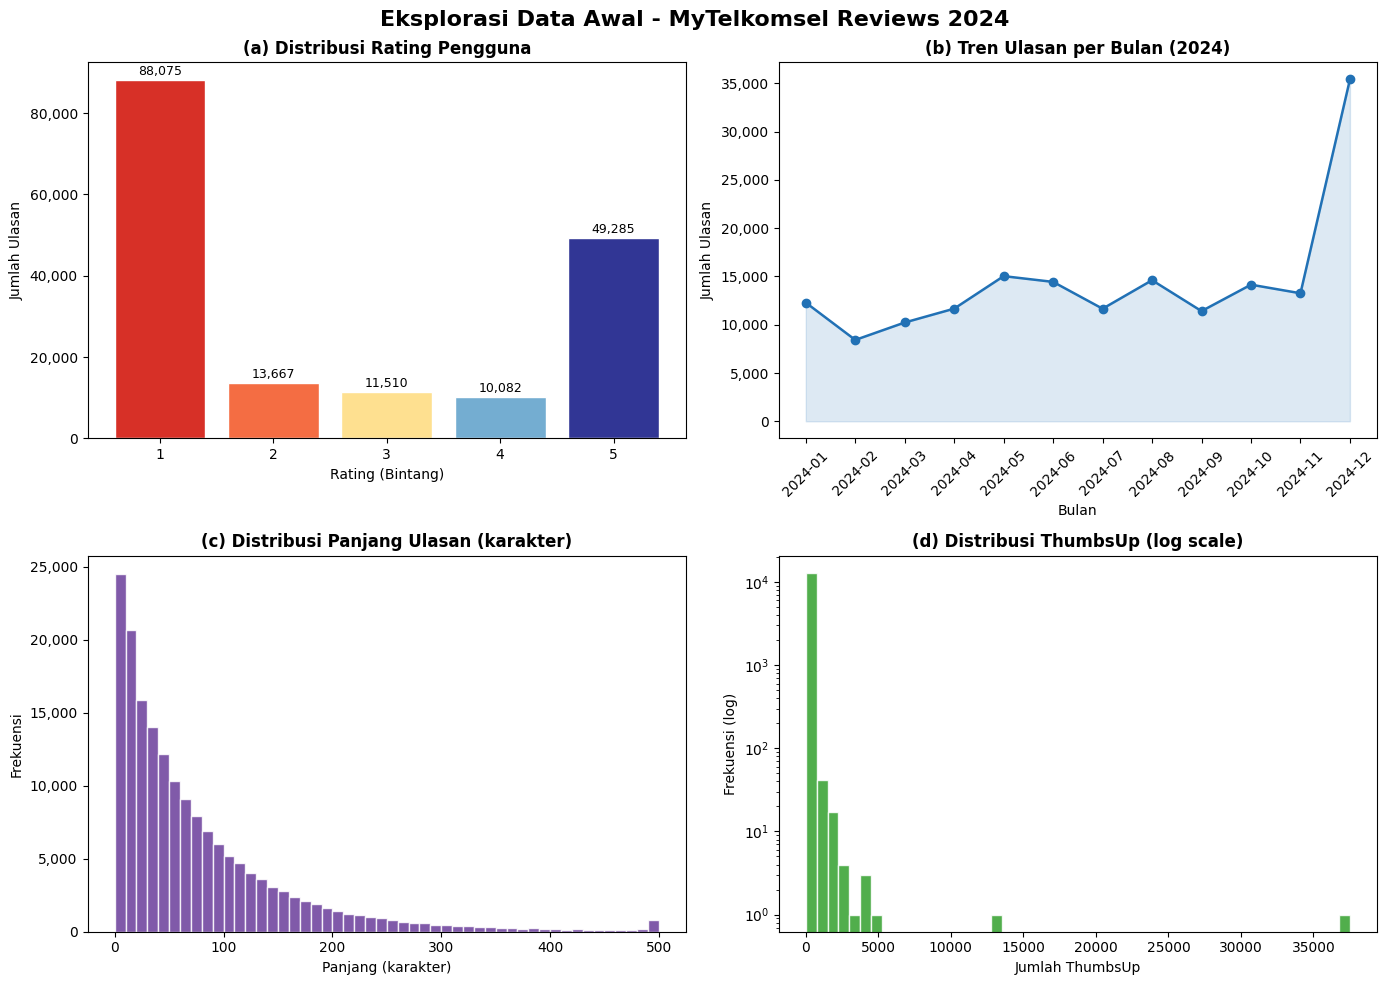

Figure 1 saved.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Eksplorasi Data Awal - MyTelkomsel Reviews 2024', fontsize=16, fontweight='bold')

ax = axes[0, 0]
colors = ['#d73027','#f46d43','#fee090','#74add1','#313695']
bars = ax.bar(rating_dist.index, rating_dist.values, color=colors, edgecolor='white')
for bar, val in zip(bars, rating_dist.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('(a) Distribusi Rating Pengguna', fontweight='bold')
ax.set_xlabel('Rating (Bintang)'); ax.set_ylabel('Jumlah Ulasan')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_xticks([1,2,3,4,5])

ax = axes[0, 1]
df['month'] = pd.to_datetime(df['at']).dt.to_period('M')
monthly = df.groupby('month').size()
monthly.index = monthly.index.astype(str)
ax.plot(monthly.index, monthly.values, marker='o', color='#2171b5', linewidth=1.8)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#2171b5')
ax.set_title('(b) Tren Ulasan per Bulan (2024)', fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Jumlah Ulasan')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax = axes[1, 0]
review_len = df['content'].fillna('').str.len()
ax.hist(review_len.clip(upper=500), bins=50, color='#6a3d9a', edgecolor='white', alpha=0.85)
ax.set_title('(c) Distribusi Panjang Ulasan (karakter)', fontweight='bold')
ax.set_xlabel('Panjang (karakter)'); ax.set_ylabel('Frekuensi')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

ax = axes[1, 1]
thumbs = df['thumbsUpCount'].clip(lower=0)
ax.hist(thumbs[thumbs > 0], bins=50, color='#33a02c', edgecolor='white', alpha=0.85, log=True)
ax.set_title('(d) Distribusi ThumbsUp (log scale)', fontweight='bold')
ax.set_xlabel('Jumlah ThumbsUp'); ax.set_ylabel('Frekuensi (log)')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'figure1_eda_4panel.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## 3. Text Preprocessing

In [6]:
stemmer_factory  = StemmerFactory()
stopword_factory = StopWordRemoverFactory()
stemmer          = stemmer_factory.create_stemmer()
stopword_remover = stopword_factory.create_stop_word_remover()
print('Sastrawi stemmer and stopword remover initialized.')

Sastrawi stemmer and stopword remover initialized.


In [7]:
def preprocess_text(text: str) -> str:
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text

print('Preprocessing function defined.')
samples = [
    'Gak bisa dibuka, error terus!!!',
    'Sangat membantu, terima kasih Telkomsel',
    'Aplikasi ini semakin hari semakin lambat',
    'KECEWA! Pulsa saya dipotong tanpa pemberitahuan',
    'Mantap, mudah digunakan'
]
print('\nSample preprocessing results (Table 13):')
for t in samples:
    print(f'  Original : {t}')
    print(f'  Processed: {preprocess_text(t)}')
    print()

Preprocessing function defined.

Sample preprocessing results (Table 13):
  Original : Gak bisa dibuka, error terus!!!
  Processed: gak buka error terus

  Original : Sangat membantu, terima kasih Telkomsel
  Processed: sangat bantu terima kasih telkomsel

  Original : Aplikasi ini semakin hari semakin lambat
  Processed: aplikasi makin hari makin lambat

  Original : KECEWA! Pulsa saya dipotong tanpa pemberitahuan
  Processed: kecewa pulsa potong pemberitahuan

  Original : Mantap, mudah digunakan
  Processed: mantap mudah guna



In [8]:
# ── Preprocessing — with cache checkpoint ───────────────────────────────────
# If telkomsel_labeled.csv already exists, load it directly (skips 30-min stemming)
_labeled_cache = os.path.join(DATA_DIR, 'telkomsel_labeled.csv')
if os.path.exists(_labeled_cache):
    print(f'Cache found! Loading df_clean from {_labeled_cache} ...')
    df_clean = pd.read_csv(_labeled_cache, parse_dates=['at'])
    print(f'Loaded {len(df_clean):,} rows — skipping stemming and signal recomputation.')
else:
    print('Running preprocessing pipeline on full dataset...')
    print('(This step is computation-heavy due to stemming — expect 10-15 minutes)')
    t0 = time.time()
    df['cleaned_content'] = (
        df['content']
        .fillna('')
        .swifter.apply(preprocess_text)
    )
    elapsed = time.time() - t0
    print(f'Preprocessing completed in {elapsed/60:.1f} minutes ({elapsed:.0f} seconds).')
    df_clean = df[df['cleaned_content'].str.strip() != ''].copy()
    removed = len(df) - len(df_clean)
    print(f'Rows removed (empty after cleaning): {removed:,} ({removed/len(df)*100:.1f}%)')
    print(f'Dataset after preprocessing: {len(df_clean):,} rows')

Cache found! Loading df_clean from /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/data/telkomsel_labeled.csv ...


Loaded 168,131 rows — skipping stemming and signal recomputation.


In [9]:
pp_path = os.path.join(DATA_DIR, 'telkomsel_preprocessed.csv')
df_clean.to_csv(pp_path, index=False)
print(f'Preprocessed data saved: {pp_path}')

Preprocessed data saved: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/data/telkomsel_preprocessed.csv


---
## 4. Multi-Signal Proxy Labeling (Churn Risk Score)

In [10]:
NEGATIVE_KEYWORDS = [
    'kecewa','buruk','jelek','parah','lambat','lemot','error','gagal',
    'susah','sulit','mahal','bohong','tipu','sampah','rusak','ribet',
    'gak bisa','tidak bisa','ngga bisa','force close','ngelag','lag',
    'lemah','busuk','worst','terburuk','nyebelin','mengecewakan'
]
POSITIVE_KEYWORDS = [
    'bagus','mantap','keren','cepat','mudah','lancar','senang','suka',
    'puas','baik','sangat membantu','membantu','nyaman','mudah digunakan',
    'stabil','recommended','rekomen','top','oke','ok'
]
CHURN_INTENT_KEYWORDS = [
    'uninstall','hapus','delete','copot',
    'pindah','ganti','indosat','xl','tri','smartfren','by.u','ioh',
    'berhenti','stop','cancel','kapok','mending',
    'worst','terburuk','jangan download','jangan pakai'
]
print(f'Keywords — Neg:{len(NEGATIVE_KEYWORDS)} Pos:{len(POSITIVE_KEYWORDS)} Churn:{len(CHURN_INTENT_KEYWORDS)}')

Keywords — Neg:28 Pos:20 Churn:21


In [11]:
# Signal 1 — Rating Score (weight 0.30): S_rating = (5 - score) / 4
df_clean['s_rating'] = (5 - df_clean['score']) / 4
print('Signal 1 (Rating Score):')
print(df_clean['s_rating'].describe().round(3))

Signal 1 (Rating Score):
count    168131.000
mean          0.631
std           0.436
min           0.000
25%           0.000
50%           1.000
75%           1.000
max           1.000
Name: s_rating, dtype: float64


In [12]:
# Signal 2 — Enhanced Sentiment Polarity (weight 0.25)
# Hybrid: TextBlob (40%) + Indonesian keyword boosting (60%)
def compute_keyword_polarity(text: str) -> float:
    if not isinstance(text, str) or text.strip() == '':
        return 0.0
    tl = text.lower()
    neg = sum(1 for kw in NEGATIVE_KEYWORDS if kw in tl)
    pos = sum(1 for kw in POSITIVE_KEYWORDS if kw in tl)
    if neg == 0 and pos == 0: return 0.0
    return (neg - pos) / (neg + pos)

def compute_enhanced_sentiment(text: str) -> float:
    if not isinstance(text, str) or text.strip() == '':
        return 0.5
    tb = TextBlob(text).sentiment.polarity
    kw = compute_keyword_polarity(text)
    combined = 0.4 * (-tb) + 0.6 * kw
    return float(np.clip((1 + combined) / 2, 0.0, 1.0))

print('Computing Signal 2 (Enhanced Sentiment Polarity)...')
t0 = time.time()
df_clean['s_sentiment'] = df_clean['content'].fillna('').swifter.apply(compute_enhanced_sentiment)
print(f'  Done in {time.time()-t0:.1f}s | Mean={df_clean["s_sentiment"].mean():.3f} Std={df_clean["s_sentiment"].std():.3f}')

Computing Signal 2 (Enhanced Sentiment Polarity)...


Pandas Apply:   0%|          | 0/168131 [00:00<?, ?it/s]

  Done in 9.8s | Mean=0.518 Std=0.229


In [13]:
# Signal 3 — Churn Intent Keywords (weight 0.25): min(matched/3, 1.0)
def compute_churn_keywords(text: str) -> float:
    if not isinstance(text, str): return 0.0
    tl = text.lower()
    return min(sum(1 for kw in CHURN_INTENT_KEYWORDS if kw in tl) / 3, 1.0)

print('Computing Signal 3 (Churn Intent Keywords)...')
t0 = time.time()
df_clean['s_keyword'] = df_clean['content'].fillna('').swifter.apply(compute_churn_keywords)
det = (df_clean['s_keyword'] > 0).sum()
print(f'  Done in {time.time()-t0:.1f}s | Detected in {det:,} reviews ({det/len(df_clean)*100:.1f}%)')

Computing Signal 3 (Churn Intent Keywords)...


Pandas Apply:   0%|          | 0/168131 [00:00<?, ?it/s]

  Done in 0.3s | Detected in 9,842 reviews (5.9%)


In [14]:
# Signal 4 — Community Agreement (weight 0.10)
cap_99 = float(df_clean['thumbsUpCount'].quantile(0.99))
print(f'99th percentile cap (thumbsUpCount): {cap_99}')

def compute_community(row) -> float:
    base = min(row['thumbsUpCount'] / cap_99, 1.0) if cap_99 > 0 else 0.0
    if row['score'] <= 2:   return base
    elif row['score'] == 3: return base * 0.5
    else:                   return 0.0

print('Computing Signal 4 (Community Agreement)...')
df_clean['s_community'] = df_clean.swifter.apply(compute_community, axis=1)
print(f'  Mean s_community: {df_clean["s_community"].mean():.4f}')

99th percentile cap (thumbsUpCount): 8.0
Computing Signal 4 (Community Agreement)...


Pandas Apply:   0%|          | 0/168131 [00:00<?, ?it/s]

  Mean s_community: 0.0195


In [15]:
# Signal 5 — Temporal Recency (weight 0.10)
# S_temporal = (date - date_min) / (date_max - date_min) * S_rating
date_min = df_clean['at'].min()
date_max = df_clean['at'].max()
date_range_s = (date_max - date_min).total_seconds()
df_clean['s_temporal'] = (
    (df_clean['at'] - date_min).dt.total_seconds() / date_range_s
) * df_clean['s_rating']
print(f'Date range: {date_min.date()} to {date_max.date()}')
print(f'Mean s_temporal: {df_clean["s_temporal"].mean():.4f}')

Date range: 2024-01-01 to 2024-12-31
Mean s_temporal: 0.3798


In [16]:
# Composite CRS
W_RATING=0.30; W_SENTIMENT=0.25; W_KEYWORD=0.25; W_COMMUNITY=0.10; W_TEMPORAL=0.10

df_clean['churn_risk_score'] = (
    W_RATING    * df_clean['s_rating']
  + W_SENTIMENT * df_clean['s_sentiment']
  + W_KEYWORD   * df_clean['s_keyword']
  + W_COMMUNITY * df_clean['s_community']
  + W_TEMPORAL  * df_clean['s_temporal']
)
THRESHOLD = 0.5
df_clean['churn_label'] = (df_clean['churn_risk_score'] >= THRESHOLD).astype(int)

print('Churn Risk Score Statistics:')
print(df_clean['churn_risk_score'].describe().round(4))
print('\nLabel Distribution:')
for lbl, cnt in df_clean['churn_label'].value_counts().sort_index().items():
    print(f'  {"Loyal (0)" if lbl==0 else "Churn (1)"}: {cnt:,} ({cnt/len(df_clean)*100:.1f}%)')

Churn Risk Score Statistics:
count    168131.0000
mean          0.3646
std           0.2013
min           0.0000
25%           0.1250
50%           0.4429
75%           0.5243
max           0.9455
Name: churn_risk_score, dtype: float64

Label Distribution:
  Loyal (0): 107,748 (64.1%)
  Churn (1): 60,383 (35.9%)


In [17]:
signal_stats = pd.DataFrame({
    'Signal' : ['S1-Rating','S2-Sentiment','S3-Keywords','S4-Community','S5-Temporal'],
    'Weight' : [0.30,0.25,0.25,0.10,0.10],
    'Mean'   : [df_clean[c].mean() for c in ['s_rating','s_sentiment','s_keyword','s_community','s_temporal']],
    'Std'    : [df_clean[c].std()  for c in ['s_rating','s_sentiment','s_keyword','s_community','s_temporal']],
})
signal_stats[['Mean','Std']] = signal_stats[['Mean','Std']].round(4)
print('Statistik Deskriptif Per-Sinyal (Table 15):')
print(signal_stats.to_string(index=False))

Statistik Deskriptif Per-Sinyal (Table 15):
      Signal  Weight   Mean    Std
   S1-Rating    0.30 0.6315 0.4359
S2-Sentiment    0.25 0.5180 0.2291
 S3-Keywords    0.25 0.0229 0.0981
S4-Community    0.10 0.0195 0.1078
 S5-Temporal    0.10 0.3798 0.3512


In [18]:
crosstab = pd.crosstab(df_clean['score'], df_clean['churn_label'], margins=True, margins_name='Total')
crosstab.columns = ['Loyal (0)','Churn (1)','Total']
crosstab['% Churn'] = (crosstab['Churn (1)'] / crosstab['Total'] * 100).round(1)
print('Cross-Tabulation: Label Churn per Rating (Table 17):')
print(crosstab.to_string())

Cross-Tabulation: Label Churn per Rating (Table 17):
       Loyal (0)  Churn (1)   Total  % Churn
score                                       
1          28311      59577   87888     67.8
2          12844        780   13624      5.7
3          11330         26   11356      0.2
4           9541          0    9541      0.0
5          45722          0   45722      0.0
Total     107748      60383  168131     35.9


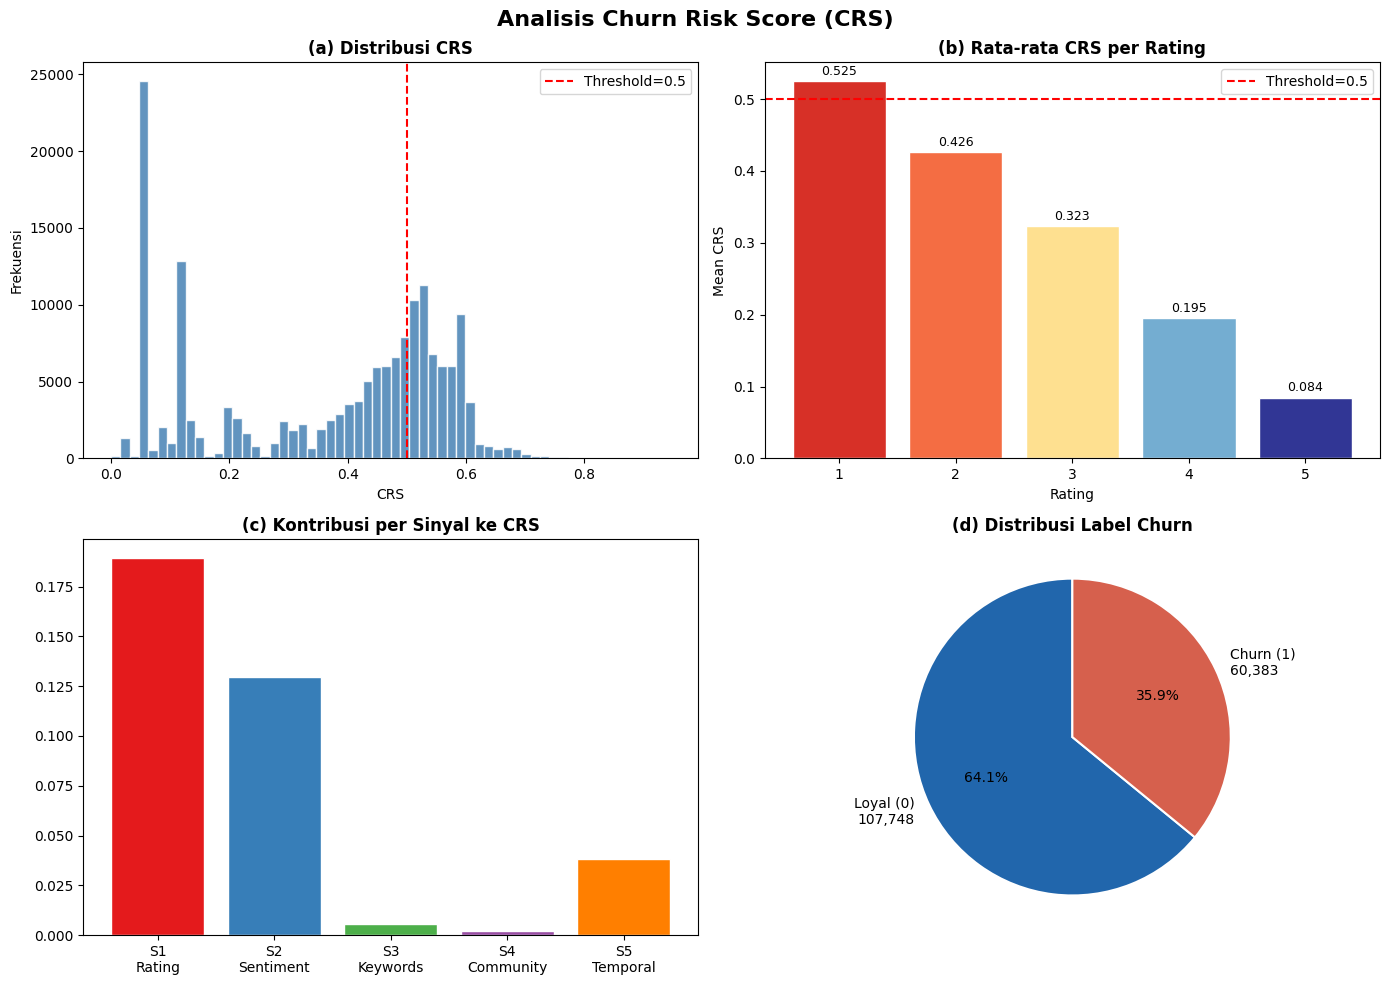

Figure 2 saved.


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Churn Risk Score (CRS)', fontsize=16, fontweight='bold')

ax = axes[0,0]
ax.hist(df_clean['churn_risk_score'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold={THRESHOLD}')
ax.set_title('(a) Distribusi CRS', fontweight='bold'); ax.set_xlabel('CRS'); ax.set_ylabel('Frekuensi'); ax.legend()

ax = axes[0,1]
crs_by_rating = df_clean.groupby('score')['churn_risk_score'].mean()
bars = ax.bar(crs_by_rating.index, crs_by_rating.values, color=['#d73027','#f46d43','#fee090','#74add1','#313695'], edgecolor='white')
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold={THRESHOLD}')
for bar,val in zip(bars,crs_by_rating.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('(b) Rata-rata CRS per Rating', fontweight='bold'); ax.set_xlabel('Rating'); ax.set_ylabel('Mean CRS'); ax.set_xticks([1,2,3,4,5]); ax.legend()

ax = axes[1,0]
sig_contrib = [df_clean[c].mean()*w for c,w in zip(['s_rating','s_sentiment','s_keyword','s_community','s_temporal'],[W_RATING,W_SENTIMENT,W_KEYWORD,W_COMMUNITY,W_TEMPORAL])]
ax.bar(['S1\nRating','S2\nSentiment','S3\nKeywords','S4\nCommunity','S5\nTemporal'], sig_contrib, color=['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00'], edgecolor='white')
ax.set_title('(c) Kontribusi per Sinyal ke CRS', fontweight='bold')

ax = axes[1,1]
cc = df_clean['churn_label'].value_counts().sort_index()
ax.pie(cc.values, labels=[f'Loyal (0)\n{cc[0]:,}',f'Churn (1)\n{cc[1]:,}'], autopct='%1.1f%%', colors=['#2166ac','#d6604d'], startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('(d) Distribusi Label Churn', fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,'figure2_crs_analysis.png'), dpi=150, bbox_inches='tight')
plt.show(); print('Figure 2 saved.')

In [20]:
labeled_path = os.path.join(DATA_DIR,'telkomsel_labeled.csv')
df_clean.to_csv(labeled_path, index=False)
print(f'Labeled data saved: {labeled_path}')

Labeled data saved: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/data/telkomsel_labeled.csv


---
## 5. Feature Engineering

In [21]:
print('Fitting TF-IDF vectorizer (max_features=1000, ngram=(1,2))...')
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1,2), strip_accents='unicode', sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df_clean['cleaned_content'].fillna(''))
print(f'TF-IDF matrix shape: {X_tfidf.shape}')

Fitting TF-IDF vectorizer (max_features=1000, ngram=(1,2))...


TF-IDF matrix shape: (168131, 1000)


In [22]:
le = LabelEncoder()
df_clean['appVersion_enc'] = le.fit_transform(df_clean['appVersion'].fillna('unknown').astype(str))
scaler = MinMaxScaler()
df_clean['thumbsUp_scaled'] = scaler.fit_transform(df_clean[['thumbsUpCount']])
X_meta = df_clean[['s_sentiment','appVersion_enc','thumbsUp_scaled']].values
print(f'Metadata matrix shape: {X_meta.shape}')
print('Metadata features: [s_sentiment, appVersion_enc, thumbsUp_scaled]')

Metadata matrix shape: (168131, 3)
Metadata features: [s_sentiment, appVersion_enc, thumbsUp_scaled]


In [23]:
X_combined = sp.hstack([X_tfidf, sp.csr_matrix(X_meta)], format='csr')
y           = df_clean['churn_label'].values
print(f'Combined feature matrix: {X_combined.shape}')
print(f'Target variable shape  : {y.shape}')

Combined feature matrix: (168131, 1003)
Target variable shape  : (168131,)


---
## 6. Data Splitting & SMOTE

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print('Train/Test Split (80/20 stratified):')
print(f'  Training: {X_train.shape[0]:,} | Loyal={(y_train==0).sum():,} Churn={(y_train==1).sum():,}')
print(f'  Test    : {X_test.shape[0]:,}  | Loyal={(y_test==0).sum():,} Churn={(y_test==1).sum():,}')

Train/Test Split (80/20 stratified):
  Training: 134,504 | Loyal=86,198 Churn=48,306
  Test    : 33,627  | Loyal=21,550 Churn=12,077


In [25]:
print('Applying SMOTE on training set only (no data leakage)...')
t0 = time.time()
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'SMOTE done in {time.time()-t0:.1f}s')
print(f'After SMOTE — Loyal={(y_train_sm==0).sum():,} Churn={(y_train_sm==1).sum():,} Total={len(y_train_sm):,}')

Applying SMOTE on training set only (no data leakage)...


SMOTE done in 41.2s
After SMOTE — Loyal=86,198 Churn=86,198 Total=172,396


---
## 7. Comparative Modeling

In [26]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                               eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0)
}
print('Models configured (Table 21):')
for name in models: print(f'  {name}')

Models configured (Table 21):
  Logistic Regression
  Random Forest
  XGBoost


In [27]:
results = {}; trained_models = {}; roc_data = {}
print('Training on SMOTE-balanced set, evaluating on original test set...\n')

for name, model in models.items():
    print(f'Training {name}...')
    t0 = time.time()
    model.fit(X_train_sm, y_train_sm)
    train_time = time.time() - t0
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    results[name] = {
        'Accuracy'       : round(accuracy_score(y_test, y_pred),4),
        'Precision'      : round(precision_score(y_test, y_pred, zero_division=0),4),
        'Recall'         : round(recall_score(y_test, y_pred, zero_division=0),4),
        'F1-Score'       : round(f1_score(y_test, y_pred, zero_division=0),4),
        'ROC-AUC'        : round(roc_auc_score(y_test, y_proba),4),
        'Training Time'  : round(train_time,2),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred, 'y_proba': y_proba
    }
    trained_models[name] = model
    roc_data[name] = roc_curve(y_test, y_proba)[:2]
    r = results[name]
    print(f'  Acc={r["Accuracy"]} Prec={r["Precision"]} Rec={r["Recall"]} F1={r["F1-Score"]} AUC={r["ROC-AUC"]} Time={r["Training Time"]}s')

print('\nAll models trained.')

Training on SMOTE-balanced set, evaluating on original test set...

Training Logistic Regression...


  Acc=0.8222 Prec=0.7187 Rec=0.8298 F1=0.7703 AUC=0.9001 Time=2.89s
Training Random Forest...


  Acc=0.8377 Prec=0.7369 Rec=0.8524 F1=0.7904 AUC=0.9117 Time=26.3s
Training XGBoost...


  Acc=0.8448 Prec=0.7336 Rec=0.8914 F1=0.8049 AUC=0.9217 Time=3.5s

All models trained.


---
## 8. Evaluation

In [28]:
metrics_df = pd.DataFrame([
    {'Model':n,'Accuracy':v['Accuracy'],'Precision':v['Precision'],'Recall':v['Recall'],
     'F1-Score':v['F1-Score'],'ROC-AUC':v['ROC-AUC'],'Training Time (s)':v['Training Time']}
    for n,v in results.items()
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('Perbandingan Performa Model (Table 22):')
print(metrics_df.to_string(index=False))

Perbandingan Performa Model (Table 22):
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training Time (s)
            XGBoost    0.8448     0.7336  0.8914    0.8049   0.9217               3.50
      Random Forest    0.8377     0.7369  0.8524    0.7904   0.9117              26.30
Logistic Regression    0.8222     0.7187  0.8298    0.7703   0.9001               2.89


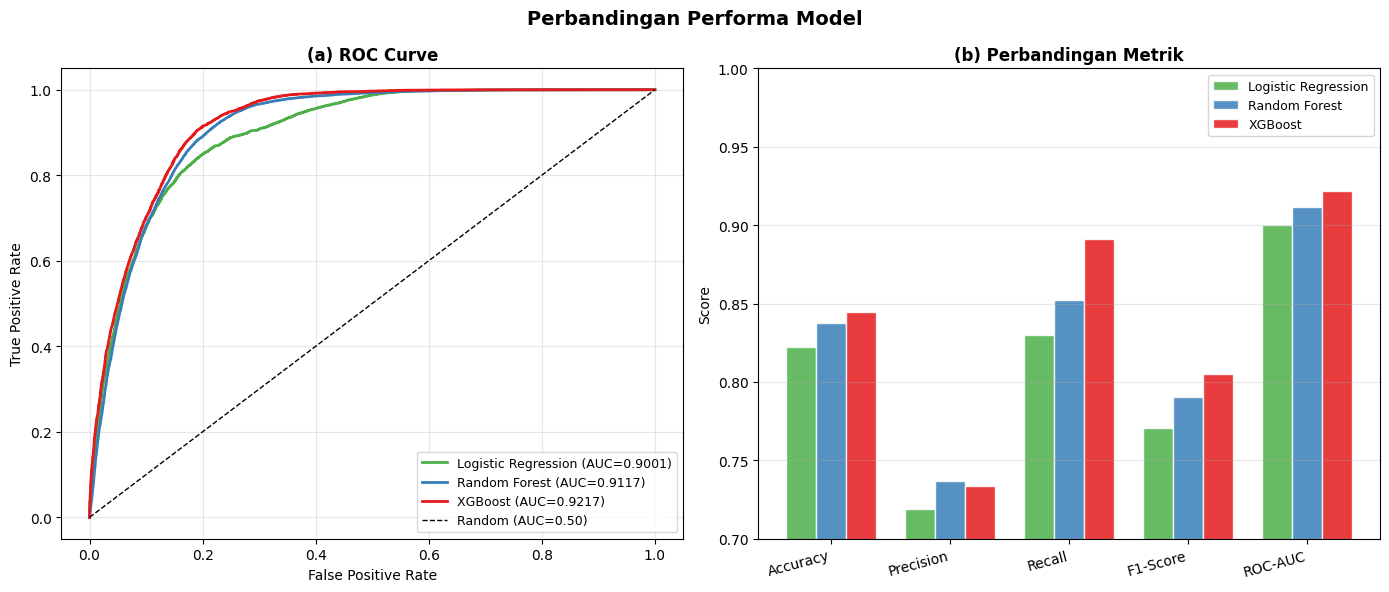

Figure 3 saved.


In [29]:
model_order  = ['Logistic Regression','Random Forest','XGBoost']
colors_model = {'XGBoost':'#e41a1c','Random Forest':'#377eb8','Logistic Regression':'#4daf4a'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Perbandingan Performa Model', fontsize=14, fontweight='bold')

ax = axes[0]
for name,(fpr,tpr) in roc_data.items():
    ax.plot(fpr, tpr, label=f'{name} (AUC={results[name]["ROC-AUC"]:.4f})', color=colors_model[name], linewidth=2)
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Random (AUC=0.50)')
ax.set_title('(a) ROC Curve', fontweight='bold'); ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate'); ax.legend(loc='lower right',fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
metric_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(metric_cols)); width = 0.25
for i,name in enumerate(model_order):
    ax.bar(x+[-width,0,width][i], [results[name][m] for m in metric_cols], width, label=name, color=colors_model[name], alpha=0.85, edgecolor='white')
ax.set_title('(b) Perbandingan Metrik', fontweight='bold'); ax.set_xticks(x); ax.set_xticklabels(metric_cols,rotation=15,ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0.7,1.0); ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,'figure3_roc_metrics.png'),dpi=150,bbox_inches='tight')
plt.show(); print('Figure 3 saved.')

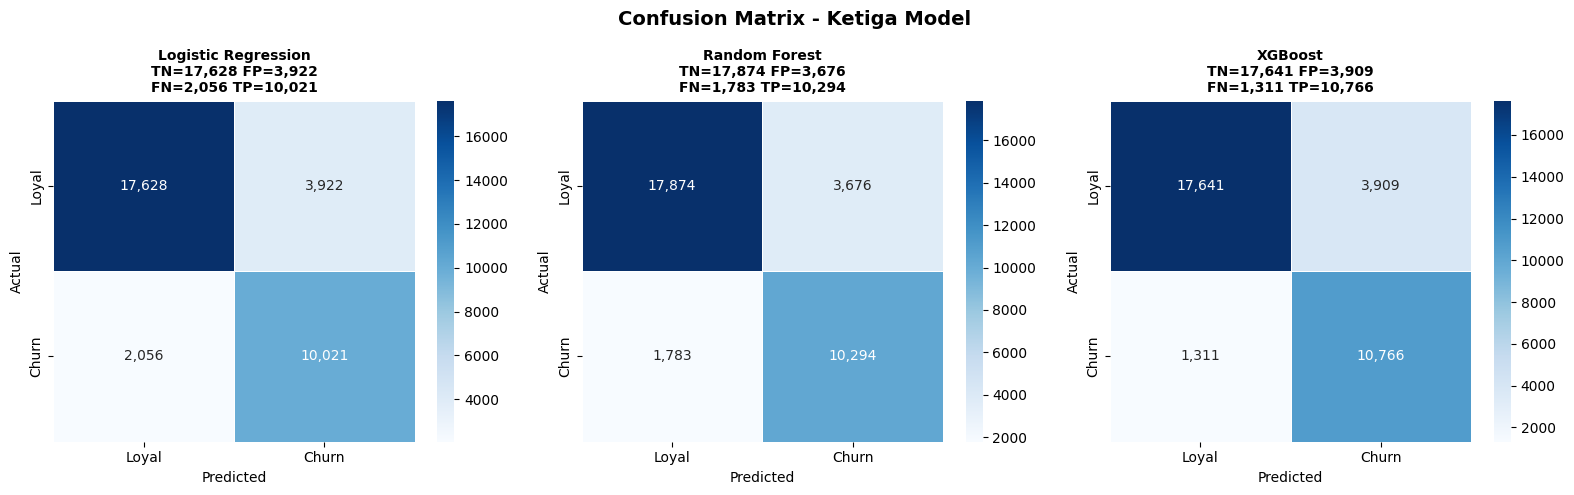

Figure 4 saved.


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrix - Ketiga Model', fontsize=14, fontweight='bold')
for ax, name in zip(axes, model_order):
    cm = results[name]['Confusion Matrix']
    sns.heatmap(cm, annot=True, fmt=',d', ax=ax, cmap='Blues', linewidths=0.5,
                xticklabels=['Loyal','Churn'], yticklabels=['Loyal','Churn'])
    tn,fp,fn,tp = cm.ravel()
    ax.set_title(f'{name}\nTN={tn:,} FP={fp:,}\nFN={fn:,} TP={tp:,}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,'figure4_confusion_matrices.png'),dpi=150,bbox_inches='tight')
plt.show(); print('Figure 4 saved.')

In [31]:
cm_rows = []
for name in model_order:
    tn,fp,fn,tp = results[name]['Confusion Matrix'].ravel()
    cm_rows.append({'Model':name,'TN':tn,'FP':fp,'FN':fn,'TP':tp})
cm_df = pd.DataFrame(cm_rows)
print('Confusion Matrix Detail (Table 23):')
print(cm_df.to_string(index=False))

best_name = metrics_df.iloc[0]['Model']
print(f'\nBest Model: {best_name} (ROC-AUC={results[best_name]["ROC-AUC"]})')
print(f'\nClassification Report - {best_name} (Table 24):')
print(classification_report(y_test, results[best_name]['y_pred'], target_names=['Loyal (0)','Churn (1)']))

Confusion Matrix Detail (Table 23):
              Model    TN   FP   FN    TP
Logistic Regression 17628 3922 2056 10021
      Random Forest 17874 3676 1783 10294
            XGBoost 17641 3909 1311 10766

Best Model: XGBoost (ROC-AUC=0.9217)

Classification Report - XGBoost (Table 24):
              precision    recall  f1-score   support

   Loyal (0)       0.93      0.82      0.87     21550
   Churn (1)       0.73      0.89      0.80     12077

    accuracy                           0.84     33627
   macro avg       0.83      0.86      0.84     33627
weighted avg       0.86      0.84      0.85     33627



---
## 9. Feature Importance & Churn Analysis

Top 10 Feature Importances (Table 25):
           Feature  Importance
sentiment_polarity    0.116852
    appVersion_enc    0.021833
           mending    0.014835
             ganti    0.012829
            pindah    0.010938
   thumbsUp_scaled    0.010393
             buruk    0.010205
             hapus    0.010025
                ya    0.009725
           tingkat    0.009576


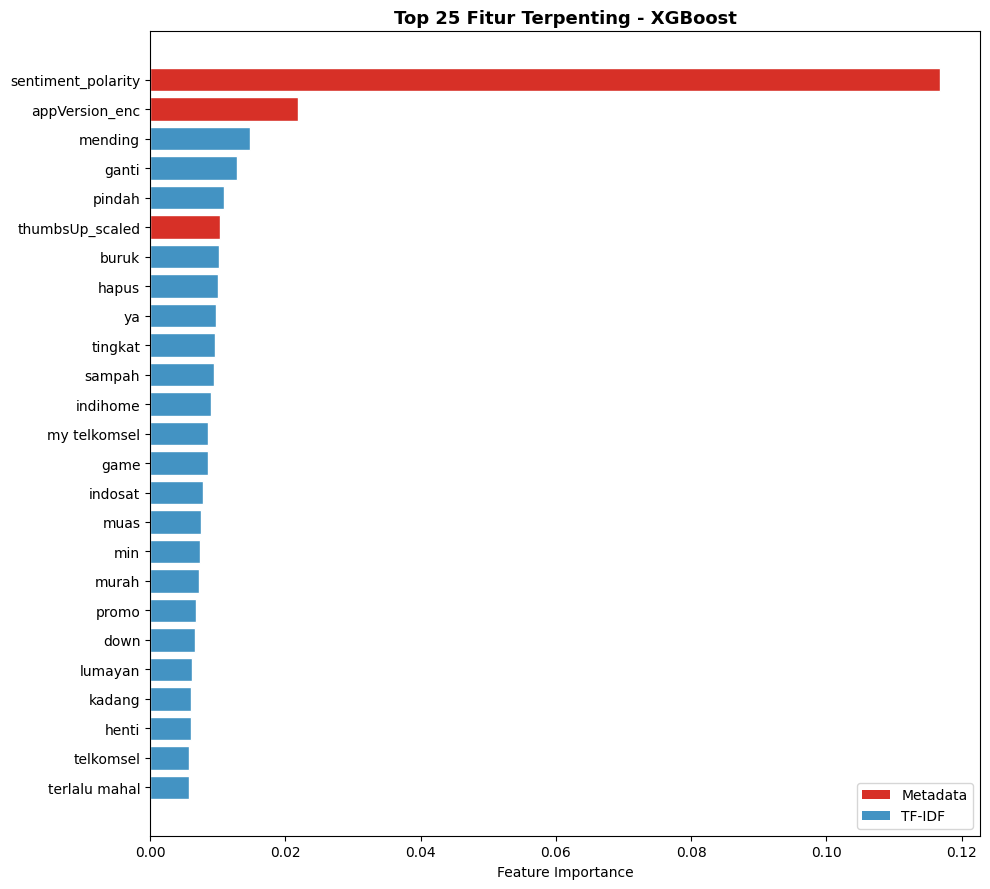

Figure 5 saved.


In [32]:
feature_names = list(tfidf.get_feature_names_out()) + ['sentiment_polarity','appVersion_enc','thumbsUp_scaled']
xgb_model     = trained_models['XGBoost']
fi_df = pd.DataFrame({'Feature':feature_names,'Importance':xgb_model.feature_importances_})\
          .sort_values('Importance',ascending=False).reset_index(drop=True)

print('Top 10 Feature Importances (Table 25):')
print(fi_df.head(10).to_string(index=False))
fi_df.to_csv(os.path.join(DATA_DIR,'feature_importance_xgboost.csv'),index=False)

fig, ax = plt.subplots(figsize=(10,9))
top25      = fi_df.head(25)
meta_feats = ['sentiment_polarity','appVersion_enc','thumbsUp_scaled']
colors_fi  = ['#d73027' if f in meta_feats else '#4393c3' for f in top25['Feature']]
ax.barh(top25['Feature'][::-1], top25['Importance'][::-1], color=colors_fi[::-1], edgecolor='white')
ax.set_title('Top 25 Fitur Terpenting - XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#d73027',label='Metadata'),Patch(facecolor='#4393c3',label='TF-IDF')], loc='lower right')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,'figure5_feature_importance_xgboost.png'),dpi=150,bbox_inches='tight')
plt.show(); print('Figure 5 saved.')

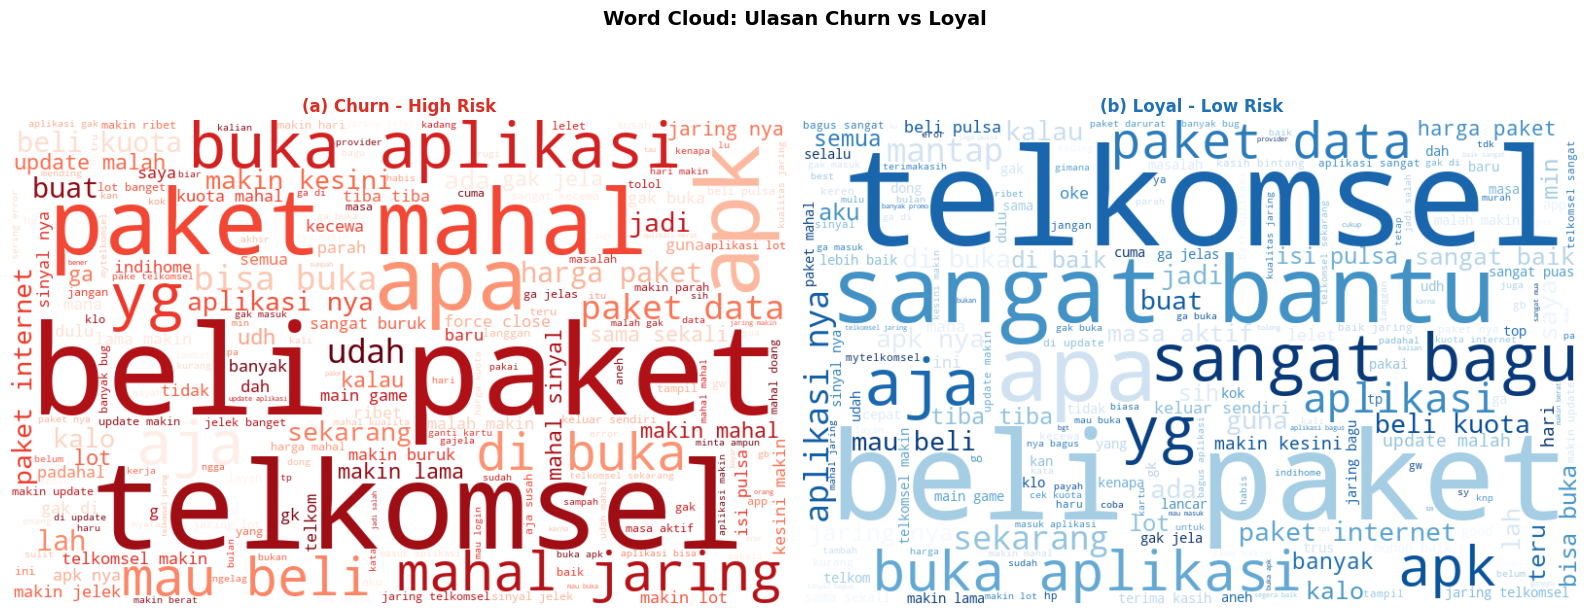

Figure 6 saved.


In [33]:
churn_text = ' '.join(df_clean[df_clean['churn_label']==1]['cleaned_content'].fillna(''))
loyal_text = ' '.join(df_clean[df_clean['churn_label']==0]['cleaned_content'].fillna(''))
fig, axes = plt.subplots(1,2,figsize=(16,7))
fig.suptitle('Word Cloud: Ulasan Churn vs Loyal', fontsize=14, fontweight='bold')
wc_c = WordCloud(width=800,height=500,background_color='white',colormap='Reds',max_words=200).generate(churn_text)
wc_l = WordCloud(width=800,height=500,background_color='white',colormap='Blues',max_words=200).generate(loyal_text)
axes[0].imshow(wc_c,interpolation='bilinear'); axes[0].axis('off'); axes[0].set_title('(a) Churn - High Risk',fontweight='bold',color='#d73027')
axes[1].imshow(wc_l,interpolation='bilinear'); axes[1].axis('off'); axes[1].set_title('(b) Loyal - Low Risk',fontweight='bold',color='#2171b5')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,'figure6_wordcloud_churn_loyal.png'),dpi=150,bbox_inches='tight')
plt.show(); print('Figure 6 saved.')

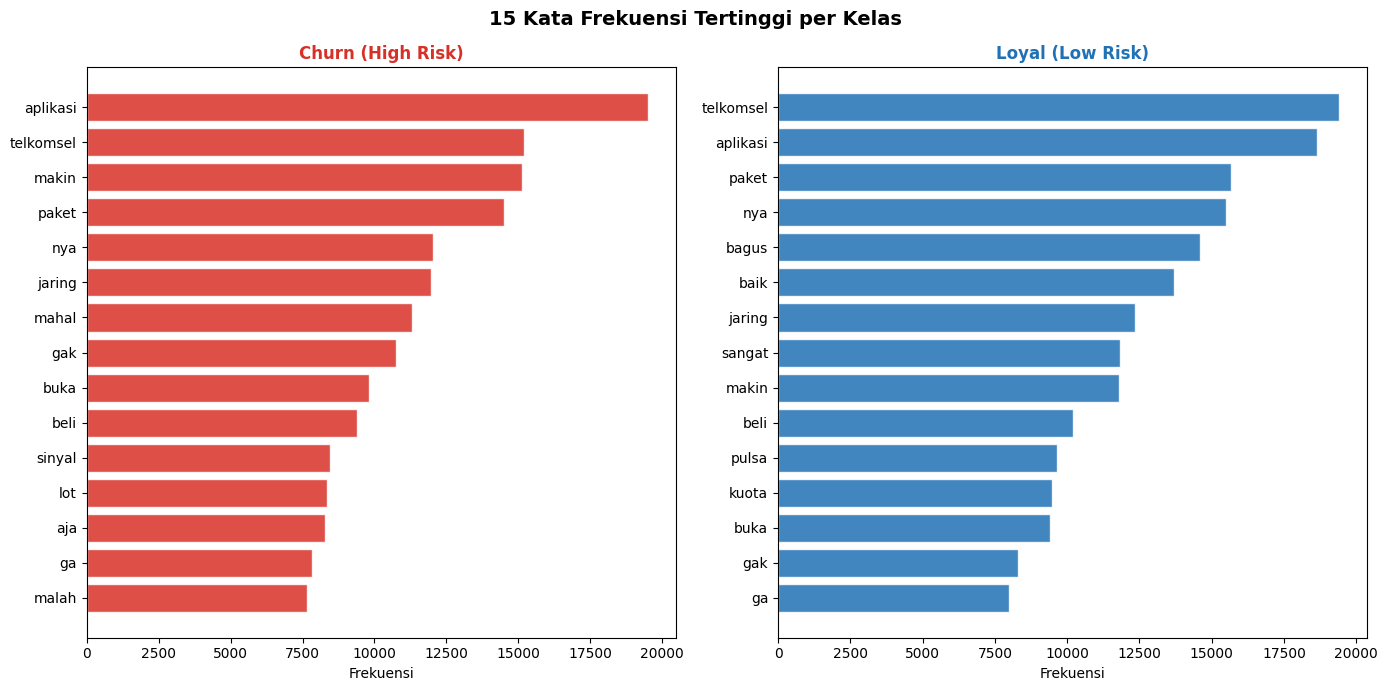

Figure 7 saved.


In [34]:
def top_n_words(series, n=15):
    return Counter(' '.join(series.fillna('')).split()).most_common(n)

churn_words = top_n_words(df_clean[df_clean['churn_label']==1]['cleaned_content'])
loyal_words = top_n_words(df_clean[df_clean['churn_label']==0]['cleaned_content'])
fig, axes = plt.subplots(1,2,figsize=(14,7))
fig.suptitle('15 Kata Frekuensi Tertinggi per Kelas', fontsize=14, fontweight='bold')
for ax,(wl,title,color) in zip(axes,[(churn_words,'Churn (High Risk)','#d73027'),(loyal_words,'Loyal (Low Risk)','#2171b5')]):
    words,freqs = zip(*wl)
    ax.barh(list(words)[::-1],list(freqs)[::-1],color=color,edgecolor='white',alpha=0.85)
    ax.set_title(title,fontweight='bold',color=color); ax.set_xlabel('Frekuensi')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR,'figure7_top15_words_per_class.png'),dpi=150,bbox_inches='tight')
plt.show(); print('Figure 7 saved.')

In [35]:
xgb_proba = results['XGBoost']['y_proba']
df_test   = df_clean.iloc[-len(y_test):].copy().reset_index(drop=True)
df_test['churn_prob_xgb'] = xgb_proba
df_test['pred_label']     = results['XGBoost']['y_pred']

top_churn = df_test[df_test['pred_label']==1].nlargest(5,'churn_prob_xgb')[['score','churn_risk_score','churn_prob_xgb','content']].reset_index(drop=True)
top_loyal = df_test[df_test['pred_label']==0].nsmallest(5,'churn_prob_xgb')[['score','churn_risk_score','churn_prob_xgb','content']].reset_index(drop=True)

print('Table 27 - Top 5 Ulasan Risiko Churn Tertinggi:')
for i,row in top_churn.iterrows():
    print(f'  {i+1}. Rating={row["score"]} CRS={row["churn_risk_score"]:.3f} P(Churn)={row["churn_prob_xgb"]:.3f}')
    print(f'     "{str(row["content"])[:100]}"')
print()
print('Table 28 - Top 5 Ulasan Loyal (Risiko Terendah):')
for i,row in top_loyal.iterrows():
    print(f'  {i+1}. Rating={row["score"]} CRS={row["churn_risk_score"]:.3f} P(Churn)={row["churn_prob_xgb"]:.3f}')
    print(f'     "{str(row["content"])[:100]}"')

Table 27 - Top 5 Ulasan Risiko Churn Tertinggi:
  1. Rating=5 CRS=0.050 P(Churn)=1.000
     "Okh"
  2. Rating=1 CRS=0.521 P(Churn)=0.999
     "gimana lah ini katanya kartu dengan sinyal ada dimana dimana tapi buat maen game onlen aja lemot kad"
  3. Rating=5 CRS=0.125 P(Churn)=0.999
     "Aplikasi lumayan bagus tapi law randem poin dan bonus selalu gagal"
  4. Rating=5 CRS=0.200 P(Churn)=0.997
     "lebih enak dibikin lah agak murah kalo pake app ini...ini sama aja sama2 mahal"
  5. Rating=5 CRS=0.050 P(Churn)=0.997
     "sangat bagus"

Table 28 - Top 5 Ulasan Loyal (Risiko Terendah):
  1. Rating=5 CRS=0.125 P(Churn)=0.000
     "0kee"
  2. Rating=4 CRS=0.131 P(Churn)=0.000
     "jaringan kurang bagus"
  3. Rating=1 CRS=0.516 P(Churn)=0.000
     "Jaringan nya sering ngeleg , kualitas murahan , tapi harga nya mahal üëéüèª"
  4. Rating=1 CRS=0.432 P(Churn)=0.000
     "Jaringan lelet,udah mahal masih lelet makin hari makin lelet kalau ada konsumen yg ngeluh harusnya s"
  5. Rating=2 CRS=

---
## 10. Save All Outputs

In [36]:
print('Saving trained models...')
for name, model in trained_models.items():
    path = os.path.join(MODELS_DIR, name.lower().replace(' ','_')+'.pkl')
    with open(path,'wb') as f: pickle.dump(model, f)
    print(f'  Saved: {path}')
for obj,fname in [(tfidf,'tfidf_vectorizer.pkl'),(le,'label_encoder_appversion.pkl'),(scaler,'minmax_scaler_thumbsup.pkl')]:
    path = os.path.join(MODELS_DIR, fname)
    with open(path,'wb') as f: pickle.dump(obj, f)
    print(f'  Saved: {path}')

Saving trained models...
  Saved: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/models/logistic_regression.pkl
  Saved: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/models/random_forest.pkl
  Saved: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/models/xgboost.pkl
  Saved: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/models/tfidf_vectorizer.pkl
  Saved: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/models/label_encoder_appversion.pkl
  Saved: /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/outputs/models/minmax_scaler_thumbsup.pkl


In [37]:
metrics_df.to_csv(os.path.join(DATA_DIR,'model_comparison_metrics.csv'),index=False)
cm_df.to_csv(os.path.join(DATA_DIR,'confusion_matrix_detail.csv'),index=False)
signal_stats.to_csv(os.path.join(DATA_DIR,'signal_statistics.csv'),index=False)
crosstab.to_csv(os.path.join(DATA_DIR,'crosstab_rating_churn.csv'))
rating_table.to_csv(os.path.join(DATA_DIR,'rating_distribution.csv'))
print('All CSVs saved.')

print()
print('='*65)
print('RINGKASAN HASIL PENELITIAN')
print('='*65)
print(f'Total ulasan awal          : {len(df):,}')
print(f'Setelah preprocessing      : {len(df_clean):,}')
print(f'  Loyal (0)               : {(df_clean["churn_label"]==0).sum():,} ({(df_clean["churn_label"]==0).mean()*100:.1f}%)')
print(f'  Churn (1)               : {(df_clean["churn_label"]==1).sum():,} ({(df_clean["churn_label"]==1).mean()*100:.1f}%)')
print(f'Feature Matrix            : {X_combined.shape[0]:,} x {X_combined.shape[1]}')
print(f'Training after SMOTE      : {len(y_train_sm):,}')
print(f'Test set                  : {len(y_test):,}')
print()
print('PERBANDINGAN PERFORMA MODEL:')
print(metrics_df.to_string(index=False))
print()
best = metrics_df.iloc[0]
print(f'MODEL TERBAIK: {best["Model"]}')
print(f'  ROC-AUC  = {best["ROC-AUC"]}')
print(f'  Recall   = {best["Recall"]}')
print(f'  F1-Score = {best["F1-Score"]}')
tn,fp,fn,tp = results[best['Model']]['Confusion Matrix'].ravel()
print(f'  TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}')
print(f'\nTop Feature: {fi_df.iloc[0]["Feature"]} (importance={fi_df.iloc[0]["Importance"]:.4f})')
print(f'\nFigures -> {FIGURES_DIR}')
print(f'Models  -> {MODELS_DIR}')
print(f'Data    -> {DATA_DIR}')
print('='*65)

All CSVs saved.

RINGKASAN HASIL PENELITIAN
Total ulasan awal          : 172,619
Setelah preprocessing      : 168,131
  Loyal (0)               : 107,748 (64.1%)
  Churn (1)               : 60,383 (35.9%)
Feature Matrix            : 168,131 x 1003
Training after SMOTE      : 172,396
Test set                  : 33,627

PERBANDINGAN PERFORMA MODEL:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training Time (s)
            XGBoost    0.8448     0.7336  0.8914    0.8049   0.9217               3.50
      Random Forest    0.8377     0.7369  0.8524    0.7904   0.9117              26.30
Logistic Regression    0.8222     0.7187  0.8298    0.7703   0.9001               2.89

MODEL TERBAIK: XGBoost
  ROC-AUC  = 0.9217
  Recall   = 0.8914
  F1-Score = 0.8049
  TN=17,641 FP=3,909 FN=1,311 TP=10,766

Top Feature: sentiment_polarity (importance=0.1169)

Figures -> /Users/marchelinaa/Library/CloudStorage/OneDrive-DANAINDONESIA/Backup/College/Thesis/Hard Cover/Program Aplikasi/o